## `plot_crosscorr.py`

In [1]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cmocean.cm as cmo

from pathlib import Path
from pycorr import TwoPointCorrelationFunction, utils, TwoPointEstimator

import src.statistics.corrfiles as cf
import src.statistics.cosmotools as ct
import importlib

cmap = cmo.thermal

v3 : 24.5 cut
v5 : 24.5 cut + downsample

In [10]:
from pycorr import utils
import cmocean.cm as cmo

importlib.reload(cf)
file_reader = cf.CorrFileReader('../crosscorr_theta/corr37_real_pip')

In [11]:
tgt1 = 'LRG'
tgt2 = 'HSC'
moc_idx = 0

In [12]:
file_reader.make_dndz(sims=0)

Using real data
Output file already exists and overwrite is set to False. 


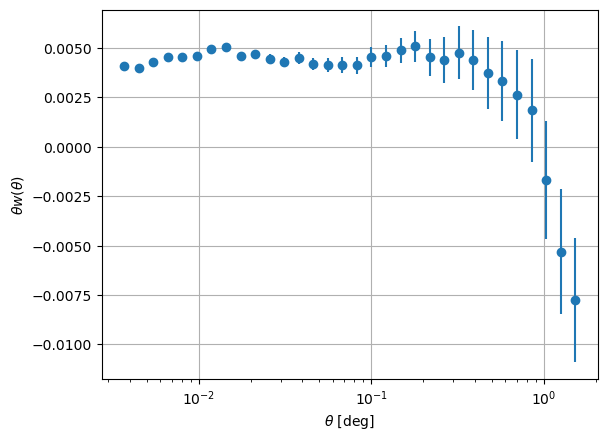

In [13]:
res = TwoPointEstimator.load(file_reader.get_file(1, 1, tgt1=tgt1, tgt2=tgt2, moc=0))
res.plot()
plt.xscale('log')

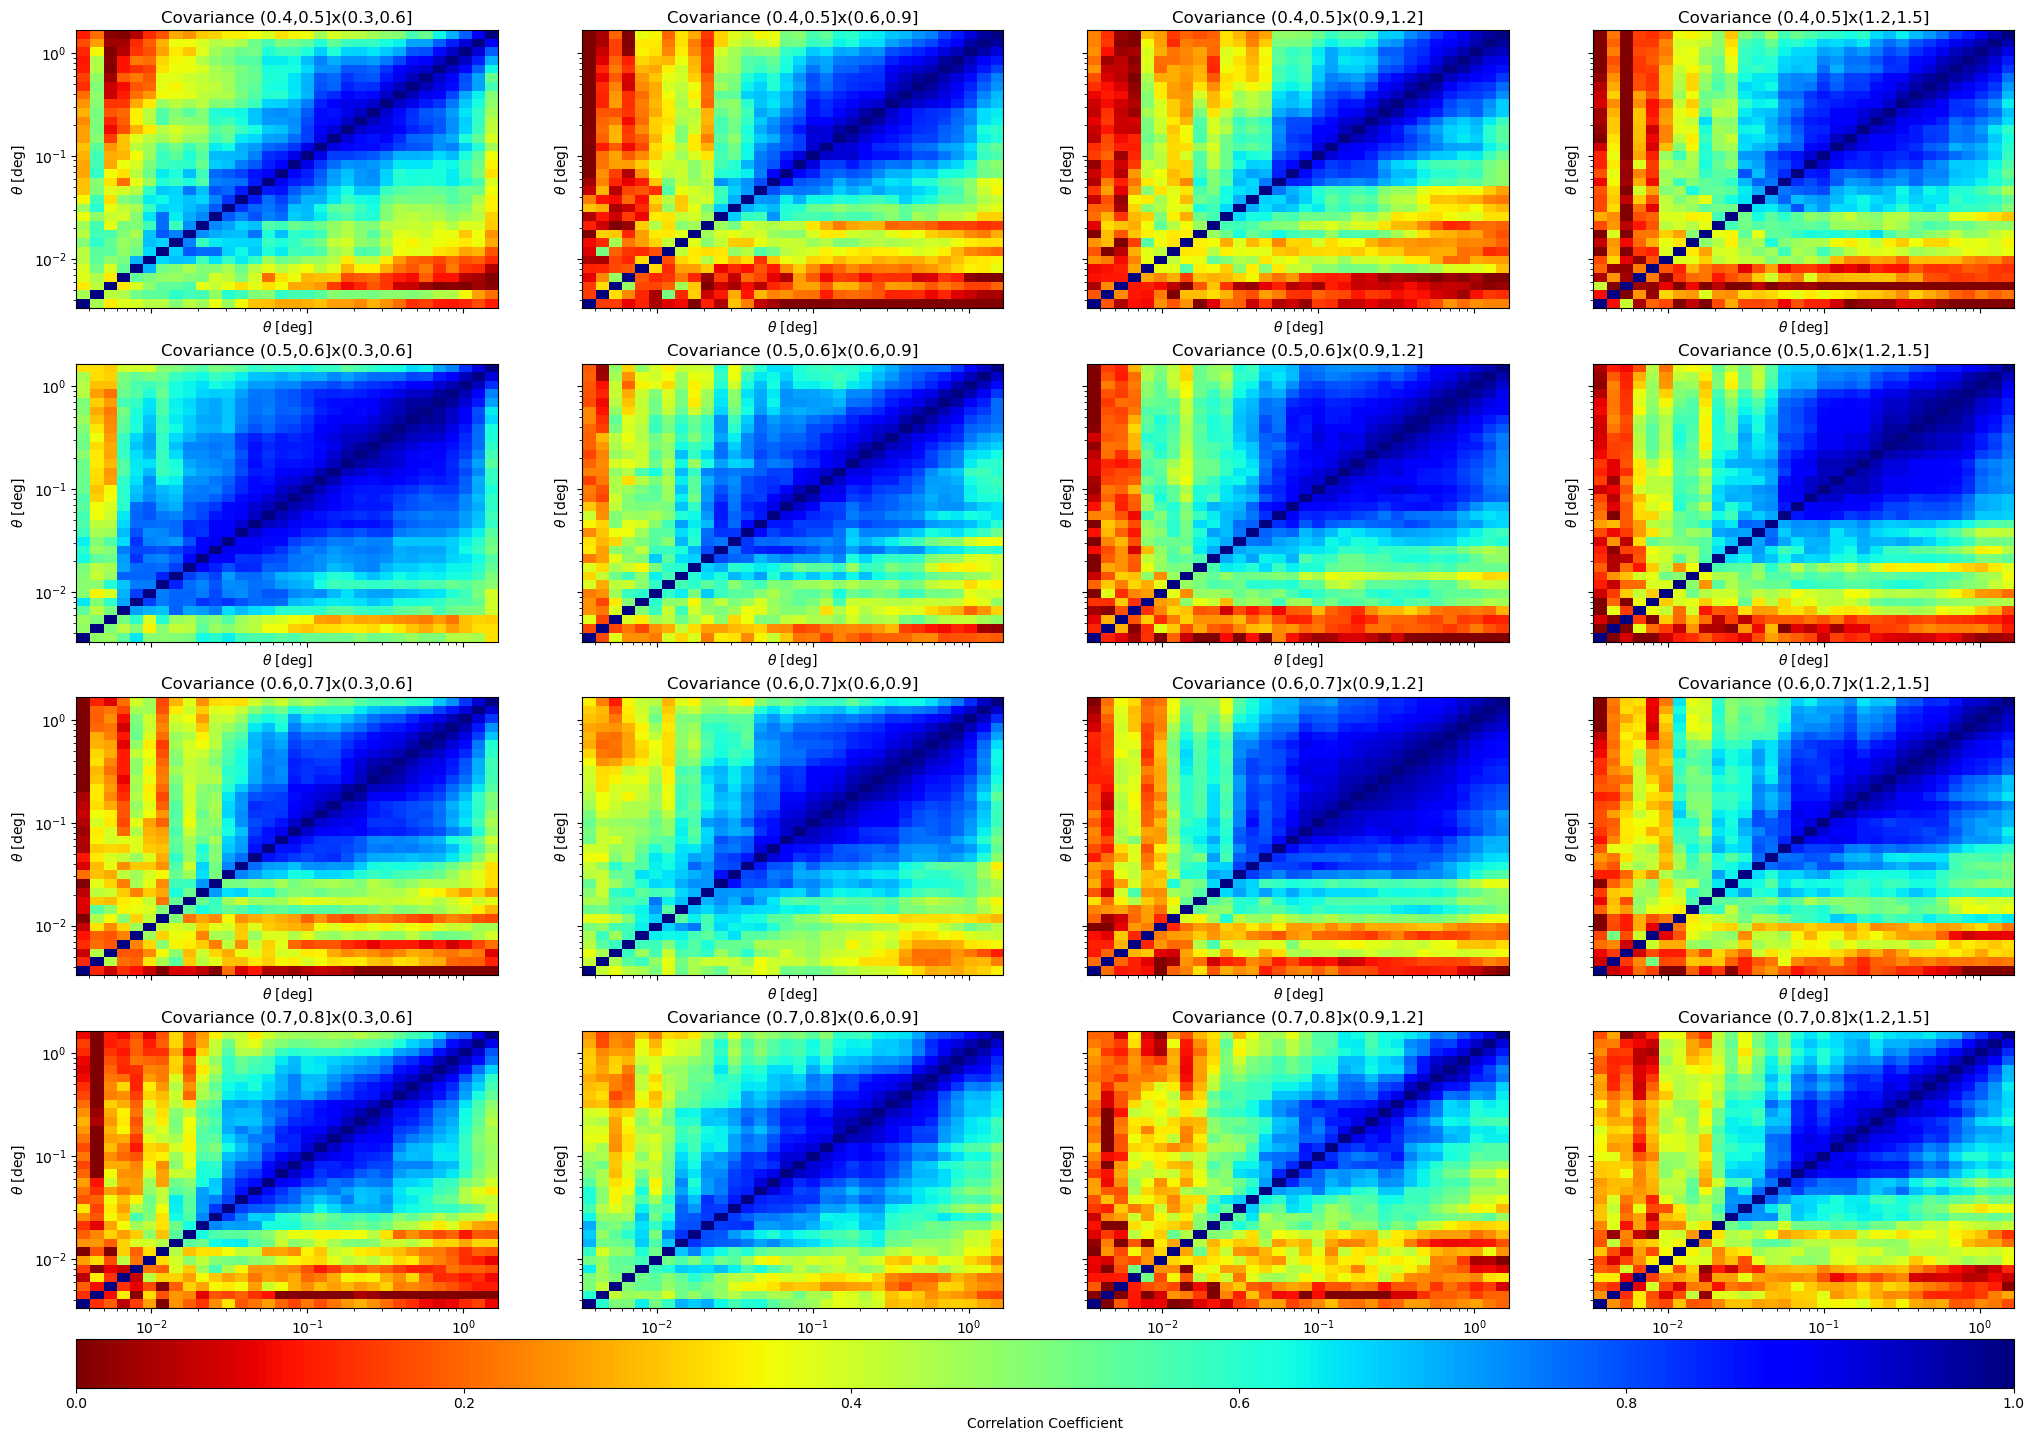

In [14]:
fig, axs = plt.subplots(4, 4, figsize=(25, 20), sharex=True, sharey=True)
bins_tgt1 = file_reader.get_bins(tgt1)
bins_tgt2 = file_reader.get_bins(tgt2)

for i in range(1, len(bins_tgt1)):
    for j in range(1, len(bins_tgt2)):
        try:
            result = TwoPointEstimator.load(
                file_reader.get_file(i, j, tgt1, tgt2, moc_idx)
                )
            #result.rebin(2)
        except FileNotFoundError:
            continue
        try:
            ax = axs[i-1, j-1]
        except IndexError:
            continue
        sep = result.sep
        cov = result.cov()

        corrcoef = utils.cov_to_corrcoef(result.cov())

        ax.pcolor(sep, sep, corrcoef.T, cmap=plt.get_cmap('jet_r'), vmin=0, vmax=1)
        ax.set_title(f'Covariance ({bins_tgt1[i-1]:.1f},{bins_tgt1[i]:.1f}]x({bins_tgt2[j-1]:.1f},{bins_tgt2[j]:.1f}]')
        ax.set_xlabel(r'$\theta$ [deg]')
        ax.set_ylabel(r'$\theta$ [deg]')
        ax.set_xscale('log')
        ax.set_yscale('log')

# Add a single colorbar for all subplots
cbar = fig.colorbar(
    axs[0, 0].collections[0], 
    ax=axs, 
    label="Correlation Coefficient", 
    orientation='horizontal', 
    pad=0.02, 
    aspect=40
    )

plt.show()

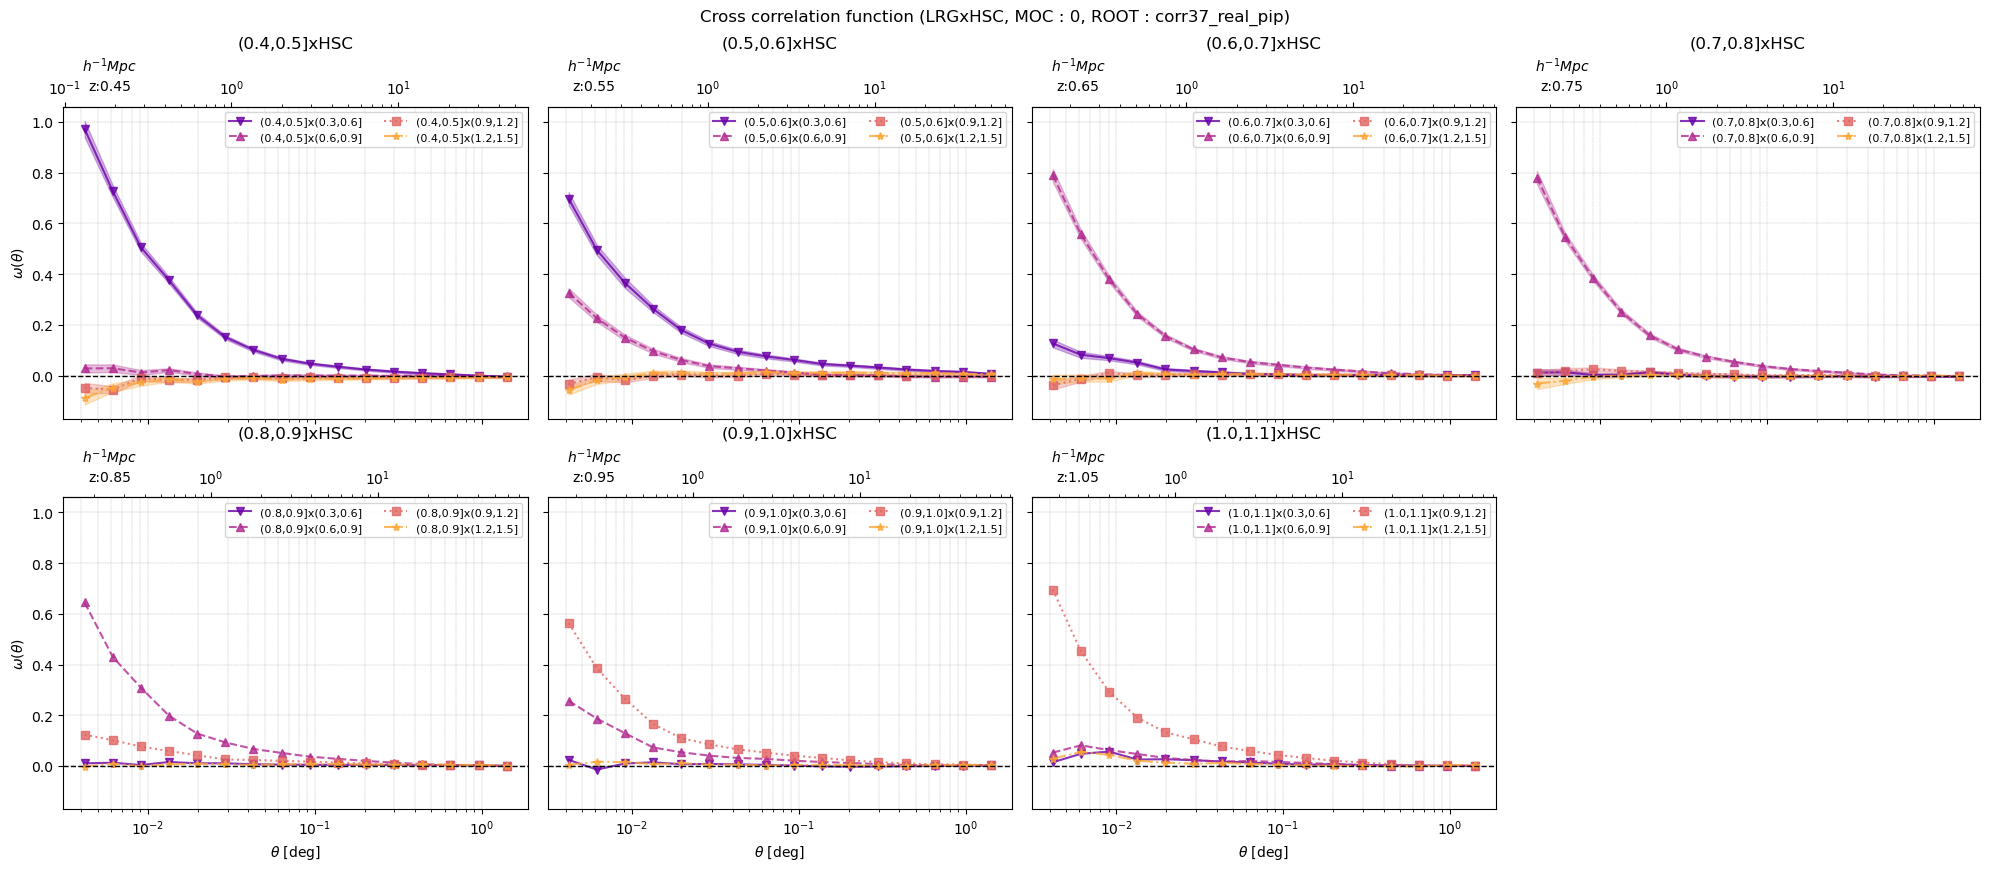

In [15]:
importlib.reload(cf)
#file_reader = cu.CorrFileReader('../crosscorr/corr23bgs/')
sepmult = False
mode = 'theta' # can also be 'rp'
normalize_by_dndz = False
rebin=2
# (2, 4) for ELGnotqso
# (2, 4) for LRG (remove last)
# (1, 4) for QSO
nrows = 2
ncols = 4
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5), sharex=True, sharey=True)
bins_tgt1 = file_reader.get_bins(tgt1)
bins_tgt2 = file_reader.get_bins(tgt2)
axs = axs.flatten()
plasma = plt.get_cmap('plasma')

if normalize_by_dndz:
    dndz_tgt1 = file_reader.get_dndz(tgt=tgt1)
    dndz_tgt2 = file_reader.get_dndz(tgt=tgt2)

exit_plot = False
for i in range(1, len(bins_tgt1)):
    for j in range(1, len(bins_tgt2)):
        nocov = False
        try:
            ax = axs[i-1]
        except IndexError:
            exit_plot = True
        try:
            cov_result = TwoPointCorrelationFunction.load(
                file_reader.get_file(i, j, tgt1, tgt2, moc_idx)
                )
            cov_result = cov_result.normalize(wnorm=1)
            if rebin > 1:
                cov_result.rebin(rebin)
        except FileNotFoundError:
            #print(f'File not found for {i}, {j}')
            continue
        
        # Define bin edges
        btgt_min, btgt_max = bins_tgt1[i-1], bins_tgt1[i]
        bhsc_min, bhsc_max = bins_tgt2[j-1], bins_tgt2[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min+1e-5 and bhsc_max >= btgt_max-1e-5 :
            #color = 'blue'  # Full overlap
            pass
        elif bhsc_max <= btgt_min+1e-5  or bhsc_min >= btgt_max-1e-5 :
            #color = plasma(j/len(bins_hsc))   # No overlap
            pass
        else:
            #color = 'black' # Partial overlap
            pass
        
        color = plasma(j/len(bins_tgt2))

        ls = '-' 
        mark = 'v'
        if j == 2:
            ls = '--'
            mark = '^'
        if j == 3:
            ls = ':'
            mark = 's'
        if j == 4:
            ls = '-.'
            mark = '*'

        sep = cov_result.sep
        try:
            cov = cov_result.cov()
            jackerr = np.sqrt(np.diag(cov))
        except AttributeError:
            nocov = True
            pass

        normalization = 1
        if normalize_by_dndz:
            normalization = np.sqrt(dndz_tgt1[i-1]*dndz_tgt2[j-1])
            pass 
        sepm = (cov_result.sep if sepmult else 1)
        if not nocov:
            ax.fill_between(
                cov_result.sep,
                sepm*(cov_result.corr-jackerr)/normalization,
                sepm*(cov_result.corr+jackerr)/normalization,
                color=color,
                alpha=0.3
            )
        ax.plot(
            cov_result.sep,
            sepm*cov_result.corr/normalization,
            mark,
            color=color,
            linestyle=ls,
            alpha=0.8,
            label=f'({bins_tgt1[i-1]:.1f},{bins_tgt1[i]:.1f}]x({bins_tgt2[j-1]:.1f},{bins_tgt2[j]:.1f}]'
        )
    if not exit_plot:
        if i > 4:
            if mode == 'theta':    
                ax.set_xlabel(r'$\theta$ [deg]')
            elif mode == 'rp':
                ax.set_xlabel(r'$r_p$ [Mpc/h]')
        if i == 1 or i == 5:
            if mode == 'theta':    
                ax.set_ylabel(r'$\omega(\theta)$' if not sepmult else r'$\theta \omega(\theta)$')
            elif mode == 'rp':
                ax.set_ylabel(r'$w_p(r_p)$' if not sepmult else r'$r_p w(r_p) [(Mpc/h)^2]$')

        ax.grid(True, which='both', linestyle='--', lw=0.3)
        ax.set_xscale('log')
        ax.axhline(0, color='k', linestyle='--', lw=1)
        ax.set_title(f'({bins_tgt1[i-1]:.1f},{bins_tgt1[i]:.1f}]x{tgt2}', fontsize=12)
        ax.legend(loc='upper right', fontsize=8, ncols=2)

        mid_z = (bins_tgt1[i-1] + bins_tgt1[i]) / 2
        tohMpc = lambda theta, z=mid_z: ct.arcsec2hMpc(theta * 3600, z=z)
        toArcsec = lambda x, z=mid_z: ct.hMpc2arcsec(x, z=z) / 3600

        if mode == 'theta':      
            # only add a secondary x-axis if the mode is 'theta' 
            secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
            secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz:{mid_z:.2f}\n')
            #secax.set_xscale('linear')
            secax.xaxis.set_label_coords(0.1, 0)

        if tgt1 == 'LRG' and not sepmult and mode == 'theta':
            #ax.set_ylim(-0.03, 0.163)
            pass
        if tgt1 == 'ELGnotqso' and not sepmult and mode == 'theta':
            ax.set_ylim(-0.055, 0.21)
            pass

fig.suptitle(f'Cross correlation function ({tgt1}x{tgt2}, MOC : {moc_idx}, ROOT : {Path(file_reader.ROOT).stem})', fontsize=12)
fig.tight_layout()

# overlap types
custom_lines = [
    mlines.Line2D([0], [0], color='blue', lw=2),
    mlines.Line2D([0], [0], color='black', lw=2),
    mlines.Line2D([0], [0], color='red', lw=2)
    ]
#fig.legend(
#    custom_lines, 
#    [
#        'Full overlap', 
#        'Partial overlap', 
#        'No overlap'
#        ], 
#    loc='lower center', 
#    ncol=3, 
#    bbox_to_anchor=(0.5, 0), 
#    fontsize=12
#    )
if tgt1 == 'LRG' or tgt1 == 'QSO':
    fig.delaxes(axs[-1])
plt.subplots_adjust(bottom=0.18)
plt.show()

In [67]:
## plotting autocorrelation

tgt = 'ELGnotqso'
file_reader = cf.CorrFileReader('../auto/auto10_nw_FKP_base/') #'../auto/auto2_real_nonKP/'
file_reader_1 = cf.CorrFileReader('../auto/auto5_real_PIP/') #'../auto/auto5_real_PIP/'
file_reader_2 = cf.CorrFileReader('../auto/auto2_real_nonKP/') #'../auto/auto4_sims_v5/'
moc_idx = 0

file_reader.make_dndz(sims=0, overwrite=True)
file_reader_1.make_dndz(sims=0, overwrite=True)
file_reader_2.make_dndz(sims=0, overwrite=True)

Using real data
Processing ELGnotqso...
Processing LRG...
Processing QSO...
Processing BGS_ANY...
Processing HSC...
Using real data
Processing ELGnotqso...
Processing LRG...
Processing QSO...
Processing BGS_ANY...
Processing HSC...
Using real data
Processing ELGnotqso...
Processing LRG...
Processing QSO...
Processing BGS_ANY...
Processing HSC...


dN/dz: [0.14359602 0.17109076 0.15124551 0.13535651 0.12370557 0.11348244
 0.09789408 0.06362912]
dN/dz (weight): [0.14359602 0.17109076 0.15124551 0.13535651 0.12370557 0.11348244
 0.09789408 0.06362912]
dN/dz (sims): [0.14359602 0.17109076 0.15124551 0.13535651 0.12370557 0.11348244
 0.09789408 0.06362912]
Comparing sims
Comparing weight
Comparing sims
Comparing weight
Comparing sims
Comparing weight
Comparing sims
Comparing weight
Comparing sims
Comparing weight
Comparing sims
Comparing weight
Comparing sims
Comparing weight
Comparing sims
Comparing weight


Text(0.5, 0.98, 'Autocorrelation function (ELGnotqso, MOC : 0)\nROOT : auto10_nw_FKP_base\nnormalization by dN/dz: True')

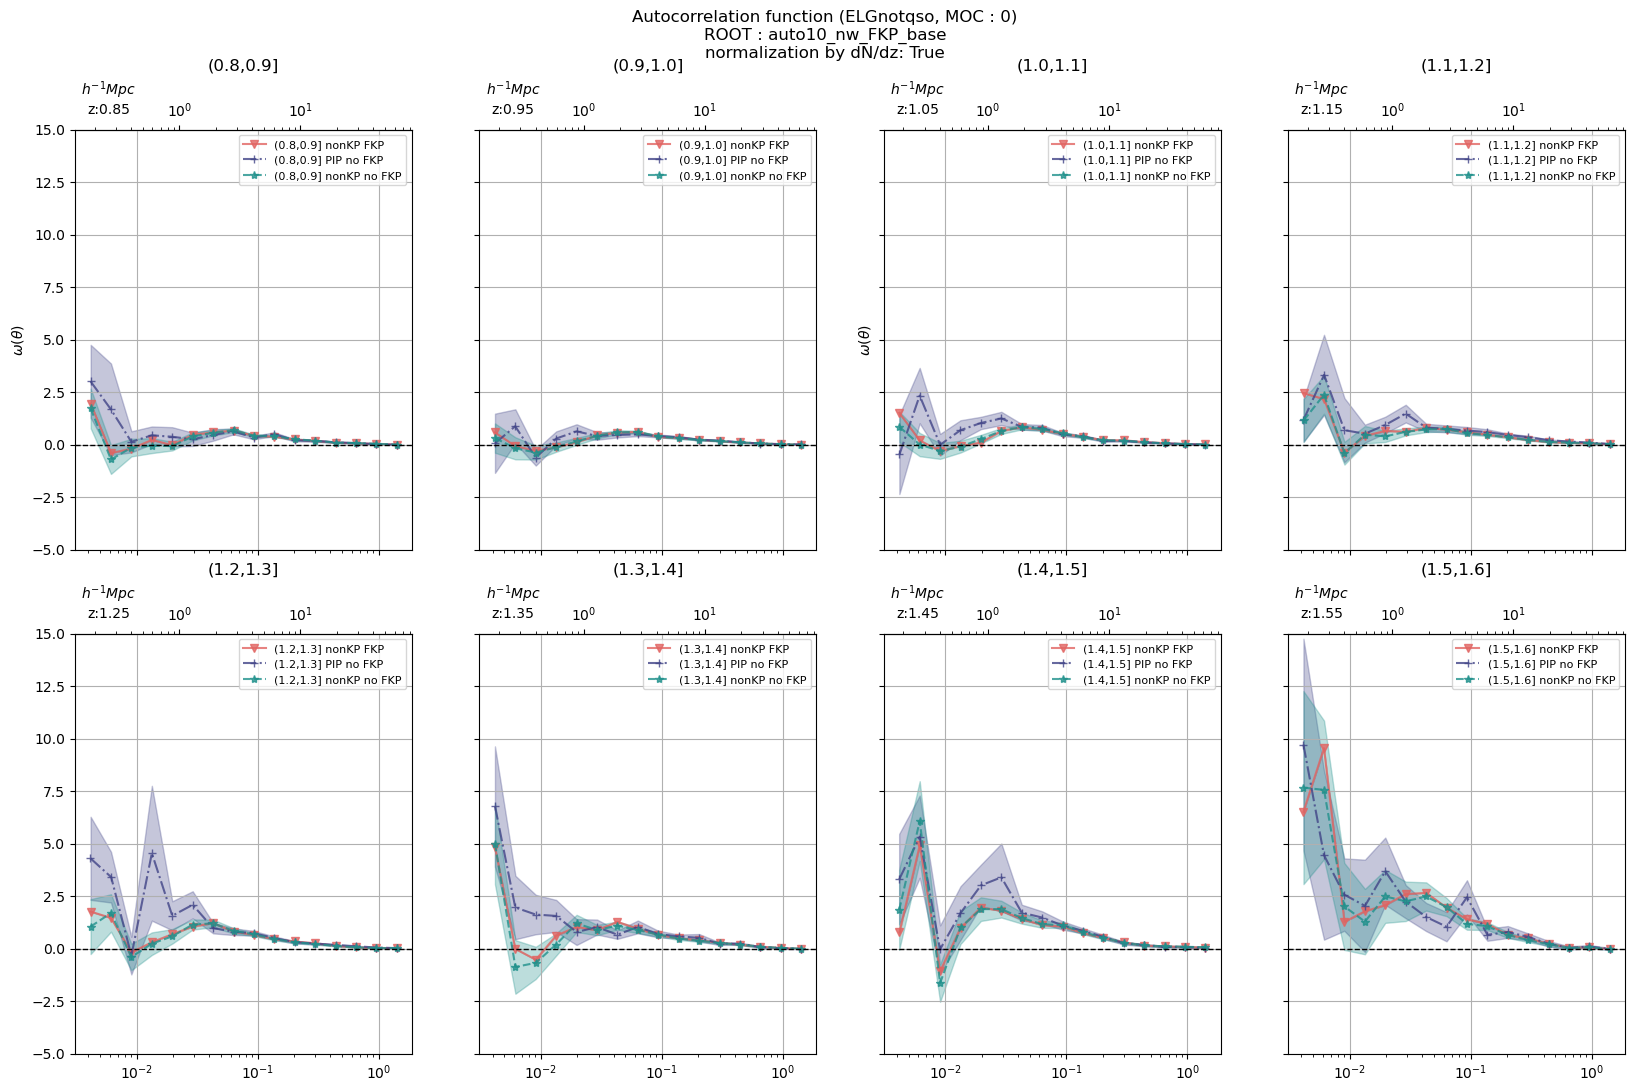

In [69]:
compare_1 = True
compare_2 = True
plot_0 = 'nonKP FKP'
plot_1 = 'PIP no FKP'
plot_2 = 'nonKP no FKP'

sepmult = False
mode = 'theta' 
normalize_by_dndz = True
rebin = 2
bins_tgt = file_reader.get_bins(tgt)
ylims = (-5, 15)
nocov = False

if normalize_by_dndz:
    try:
        dndz_tgt1 = file_reader.get_dndz(tgt)
        print(f'dN/dz: {dndz_tgt1}')
    except ValueError:
        pass
    try:
        dndz_tgt_1 = file_reader_1.get_dndz(tgt)
        print(f'dN/dz (weight): {dndz_tgt_1}')
    except ValueError:
        compare_2 = False
        pass
    try:
        dndz_tgt_2 = file_reader_2.get_dndz(tgt)
        print(f'dN/dz (sims): {dndz_tgt_2}')
    except ValueError:
        compare_2 = False
        pass

nrows = 2
ncols = len(bins_tgt)//2
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5+2), sharex=True, sharey=True)
plasma = plt.get_cmap('plasma')
viridis = plt.get_cmap('viridis')
axs = axs.flatten()

for ind in range(1, len(bins_tgt)):
    mid_z = (bins_tgt[ind-1] + bins_tgt[ind]) / 2

    ax = axs[ind-1]
    if ind == 0:
        continue
    try:
        cov_result = TwoPointCorrelationFunction.load(
            file_reader.get_file(ind, ind, tgt, tgt, moc_idx)
            )
        if rebin > 1:
            cov_result.rebin(rebin)
    except FileNotFoundError:
        #print(f'File not found for {i}, {j}')
        pass
    if compare_2:
        try:
            cov_result_2 = TwoPointCorrelationFunction.load(
                file_reader_2.get_file(ind, ind, tgt, tgt, moc_idx)
                )
            if rebin > 1:
                cov_result_2.rebin(rebin)
            print(f'Comparing sims')
        except FileNotFoundError:
            compare_2 = False
            pass
    if compare_2:
        try:
            cov_result_1 = TwoPointCorrelationFunction.load(
                file_reader_1.get_file(ind, ind, tgt, tgt, moc_idx)
                )
            if rebin > 1:
                cov_result_1.rebin(rebin)
            print(f'Comparing weight')
        except FileNotFoundError:
            compare_2 = False
            pass

    
    # Define bin edges
    btgt_min, btgt_max = bins_tgt[ind-1], bins_tgt[ind]

    ls = '-' 
    mark = 'v'
    color = plasma(0.6)

    ls_2 = '--'
    mark_2 = '*'
    color_2 = viridis(0.5)

    ls_1 = '-.'
    mark_1 = '+'
    color_1 = viridis(0.2)

    sep = cov_result.sep
    try:
        cov = cov_result.cov()
        jackerr = np.sqrt(np.diag(cov))
    except AttributeError:
        nocov = True
        jackerr = np.zeros_like(cov_result.corr)
        pass

    normalization = 1
    if normalize_by_dndz:
        normalization = dndz_tgt1[ind-1]
        pass 
    sepm = (cov_result.sep if sepmult else 1)
    ax.fill_between(
        cov_result.sep,
        sepm*(cov_result.corr-jackerr)/normalization,
        sepm*(cov_result.corr+jackerr)/normalization,
        color=color,
        alpha=0.3
    )
    ax.plot(
        cov_result.sep,
        sepm*cov_result.corr/normalization,
        mark,
        color=color,
        linestyle=ls,
        alpha=0.8,
        label=f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}] {plot_0}'
    )
    if compare_2:
        if normalize_by_dndz:
            normalization = dndz_tgt_1[ind-1]
        try:
            jackerr_1 = np.sqrt(np.diag(cov_result_1.cov()))
        except AttributeError:
            nocov = True
            jackerr_1 = np.zeros_like(cov_result_1.corr)
            pass
        ax.plot(
            cov_result_1.sep,
            sepm*cov_result_1.corr/normalization,
            mark_1,
            color=color_1,
            linestyle=ls_1,
            alpha=0.8,
            label=f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}] {plot_1}'
        )
        ax.fill_between(
            cov_result_2.sep,
            sepm*(cov_result_1.corr-jackerr_1)/normalization,
            sepm*(cov_result_1.corr+jackerr_1)/normalization,
            color=color_1,
            alpha=0.3
        )
    if compare_2:
        if normalize_by_dndz:
            normalization = dndz_tgt_2[ind-1]
        try:
            jackerr_2 = np.sqrt(np.diag(cov_result_2.cov()))
        except AttributeError:
            nocov = True
            jackerr_2 = np.zeros_like(cov_result_2.corr)
            pass
        ax.plot(
            cov_result_2.sep,
            sepm*cov_result_2.corr/normalization,
            mark_2,
            color=color_2,
            linestyle=ls_2,
            alpha=0.8,
            label=f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}] {plot_2}'
        )
        ax.fill_between(
            cov_result_2.sep,
            sepm*(cov_result_2.corr-jackerr_2)/normalization,
            sepm*(cov_result_2.corr+jackerr_2)/normalization,
            color=color_2,
            alpha=0.3
        )
    if ind > nrows*ncols:
        if mode == 'theta':    
            ax.set_xlabel(r'$\theta$ [deg]')
        elif mode == 'rp':
            ax.set_xlabel(r'$r_p$ [Mpc/h]')
    if ind == 1 or ind == ncols//2+1:
        if mode == 'theta':    
            ax.set_ylabel(
                r'$\omega(\theta)$' if not sepmult else r'$\theta \omega(\theta)$'
                + (r'/(dN/dz)' if normalize_by_dndz else '')
                )
        elif mode == 'rp':
            ax.set_ylabel(r'$w_p(r_p)$' if not sepmult else r'$r_p w(r_p) [(Mpc/h)^2]$')
    ax.set_xscale('log')
    ax.axhline(0, color='k', linestyle='--', lw=1)
    ax.set_title(f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}]', fontsize=12)
    ax.grid()
    secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
    secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz:{mid_z:.2f}\n')
    #secax.set_xscale('linear')
    secax.xaxis.set_label_coords(0.1, 0)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(ylims[0], ylims[1])

if tgt == 'LRG':
    fig.delaxes(axs[-1])

fig.suptitle(
    f'Autocorrelation function ({tgt}, MOC : {moc_idx})' 
    f'\nROOT : {Path(file_reader.ROOT).stem}\n'
    f'normalization by dN/dz: {normalize_by_dndz}',
)
            

In [53]:
lrg = fio.FITS('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/LRG_SGC_clustering.dat.fits')

In [54]:
lrg[1].get_colnames()

['TARGETID',
 'Z',
 'NTILE',
 'RA',
 'DEC',
 'PHOTSYS',
 'FRAC_TLOBS_TILES',
 'WEIGHT_ZFAIL',
 'WEIGHT_IMLIN',
 'WEIGHT_SYS',
 'WEIGHT',
 'WEIGHT_COMP',
 'NX',
 'WEIGHT_FKP']

Text(0.5, 1.0, 'LRG WEIGHT distribution')

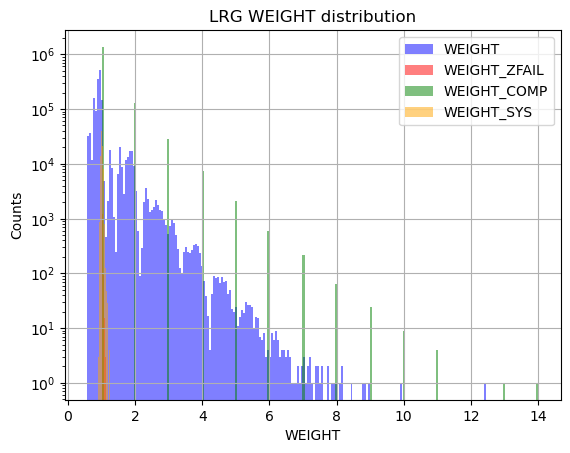

In [55]:
plt.hist(lrg[1]['WEIGHT'].read(), bins=200, alpha=0.5, color='blue', label='WEIGHT')
plt.hist(lrg[1]['WEIGHT_ZFAIL'].read(), bins=200, alpha=0.5, color='red', label='WEIGHT_ZFAIL')
plt.hist(lrg[1]['WEIGHT_COMP'].read(), bins=200, alpha=0.5, color='green', label='WEIGHT_COMP')
plt.hist(lrg[1]['WEIGHT_SYS'].read(), bins=200, alpha=0.5, color='orange', label='WEIGHT_SYS')

plt.legend()
plt.grid()
plt.title('LRG WEIGHT distribution')
plt.yscale('log')
plt.xlabel('WEIGHT')
plt.ylabel('Counts')
plt.title('LRG WEIGHT distribution')

In [44]:
import math
logbins = np.logspace(math.log(1, 10), math.log(250, 10), 26, base=10)/60

In [ ]:
print(np.logspace(math.log(0.2, 10), math.log(200, 10), 26, base=10)/60)
print(np.logspace(math.log(2.5, 10), math.log(250, 10), 21, base=10)/60)

[0.00833333 0.01059013 0.01345809 0.01710275 0.02173443 0.02762045
 0.03510049 0.04460623 0.05668628 0.07203779 0.09154671 0.11633895
 0.14784531 0.18788407 0.23876593 0.30342737 0.38560011 0.49002648
 0.6227331  0.79137868 1.00569606 1.27805383 1.62417023 2.06402021
 2.62298825 3.33333333]
[0.04166667 0.05245523 0.06603722 0.08313593 0.10466193 0.13176157
 0.16587799 0.20882801 0.26289889 0.3309701  0.41666667 0.52455225
 0.66037216 0.8313593  1.04661935 1.31761569 1.65877988 2.08828014
 2.62898894 3.30970098 4.16666667]


In [31]:
0.1*60

6.0

In [59]:
import src.statistics.cosmotools as ct 
import math
print(
    [
        float(f'{a:.3f}')
        for a in ct.arcsec2hMpc(np.logspace(math.log(0.2, 10), math.log(200, 10), 21, base=10)*60, 1)
    ]
    )

[0.146, 0.206, 0.291, 0.411, 0.581, 0.821, 1.16, 1.638, 2.314, 3.268, 4.617, 6.521, 9.211, 13.011, 18.379, 25.961, 36.67, 51.798, 73.167, 103.351, 145.987]


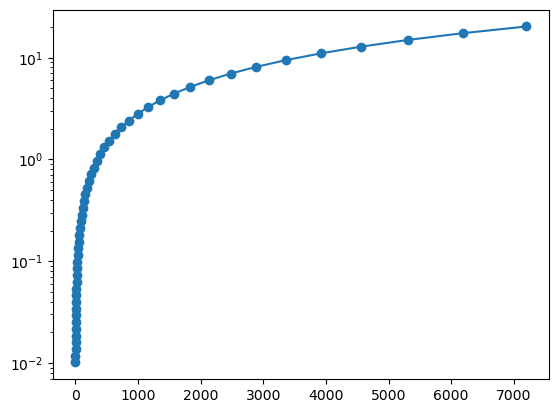

In [ ]:

bins_angular = 3600*np.logspace(
        np.log(0.001), 
        np.log(2), 
        51,
        base=np.e
    )
bins_mpc = ct.arcsec2hMpc(bins_angular, z=0.1)
plt.plot(bins_angular, bins_mpc, 'o-')
plt.yscale('log')

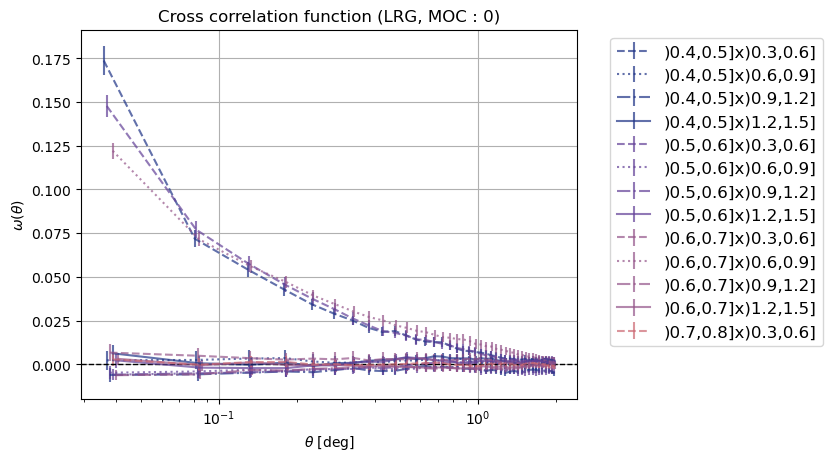

In [46]:
bhsc = file_reader.get_bins('HSC')
btgt = file_reader.get_bins(tgt)

for i in range(1, 6):
    for j in range(1, len(bhsc)):
        try:
            result = TwoPointCorrelationFunction.load(
                file_reader.get_file(i, j, tgt, 'HSC', moc_idx)
                )
        except:
            continue
        ls = '-' 
        if j == 1:
            ls = '--'
        if j == 2:
            ls = ':'
        if j == 3:
            ls = '-.'
        plt.errorbar(
            result.sep+0.001*j+0.001*i, 
            result.corr, 
            yerr=np.sqrt(np.diag(result.cov())),
            alpha=0.7,
            linestyle=ls,
            label=f'){btgt[i-1]:.1f},{btgt[i]:.1f}]x){bhsc[j-1]:.1f},{bhsc[j]:.1f}]',
            color=cmap(i/(len(btgt)-1)),
            )
plt.xscale('log')
plt.title(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\omega(\theta)$')
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid()

/tmp/ipykernel_1243889/45142904.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=8, ncols=2)


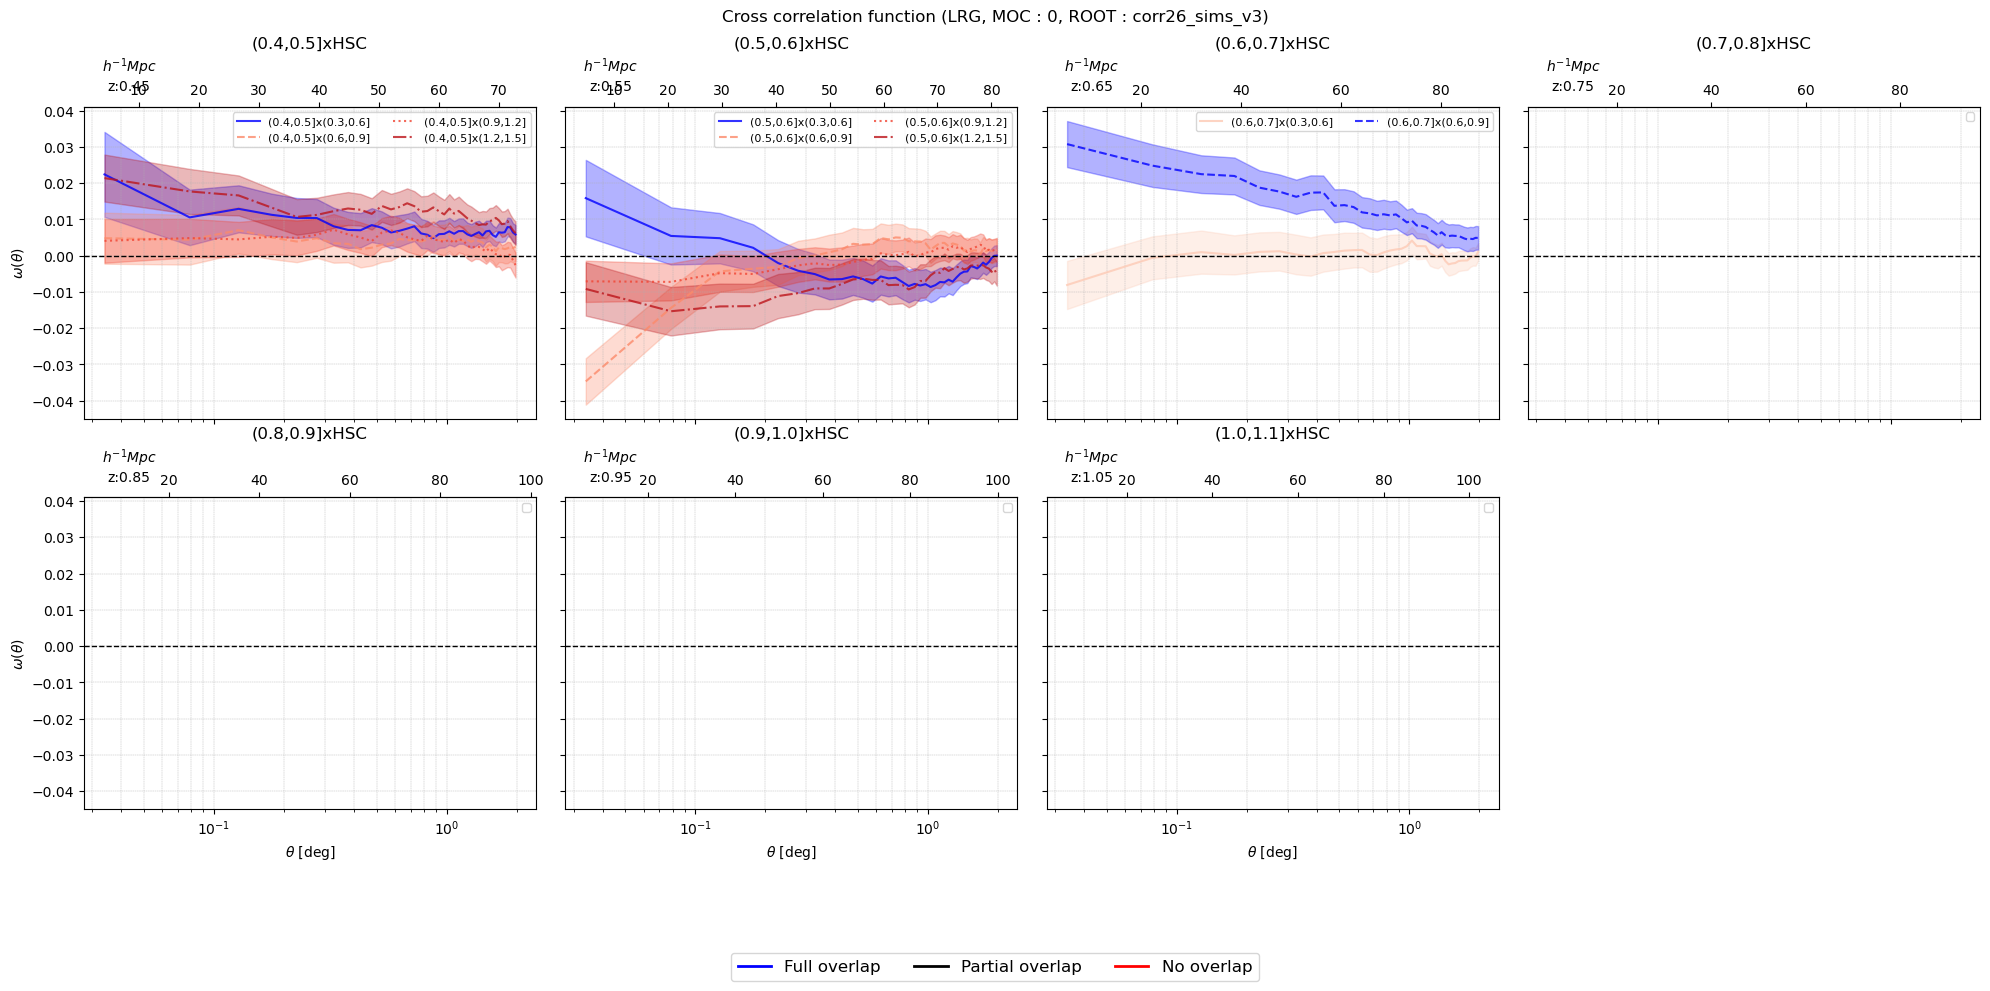

In [ ]:
importlib.reload(cu)
file_reader2 = cu.CorrFileReader('../crosscorr/old/run19/LRGxHSC/')
sepmult = False

# (2, 4) for ELGnotqso
# (2, 4) for LRG (remove last)
# (1, 4) for QSO
nrows = 2
ncols = 4
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5), sharex=True, sharey=True)
bins_tgt = file_reader.get_bins(tgt)
bins_hsc = file_reader.get_bins('HSC')
axs = axs.flatten()

exit_plot = False
for i in range(1, len(bins_tgt)):
    for j in range(1, len(bins_hsc)):
        try:
            ax = axs[i-1]
        except IndexError:
            exit_plot = True
        try:
            cov_result = TwoPointCorrelationFunction.load(
                file_reader.get_file(i, j, tgt, 'HSC', moc_idx)
                )
            cov_result_real = TwoPointCorrelationFunction.load(
                file_reader2.get_file(i, j, tgt, 'HSC', moc_idx)
                )
        except FileNotFoundError:
            #print(f'File not found for {i}, {j}')
            continue
        
        # Define bin edges
        btgt_min, btgt_max = bins_tgt[i-1], bins_tgt[i]
        bhsc_min, bhsc_max = bins_hsc[j-1], bins_hsc[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min+1e-5 and bhsc_max >= btgt_max-1e-5 :
            color = 'blue'  # Full overlap
        elif bhsc_max <= btgt_min+1e-5  or bhsc_min >= btgt_max-1e-5 :
            color = plt.get_cmap('Reds')(j/len(bins_hsc))   # No overlap
        else:
            color = 'black' # Partial overlap

        ls = '-' 
        if j == 2:
            ls = '--'
        if j == 3:
            ls = ':'
        if j == 4:
            ls = '-.'

        sep = cov_result.sep
        cov = cov_result.cov()
        cov_real = cov_result_real.cov()

        jackerr = np.sqrt(np.diag(cov))
        jackerr_real = np.sqrt(np.diag(cov_real))
        jack = np.sqrt(jackerr**2 + jackerr_real**2)
        cov_diff = cov_result.corr - cov_result_real.corr
        ax.fill_between(
            cov_result.sep,
            (cov_result.sep if sepmult else 1)*(cov_diff - jack),
            (cov_result.sep if sepmult else 1)*(cov_diff + jack),
            color=color,
            alpha=0.3
        )
        ax.plot(
            cov_result.sep,
            (cov_result.sep if sepmult else 1)*(cov_result.corr - cov_result_real.corr),
            color=color,
            linestyle=ls,
            alpha=0.8,
            label=f'({bins_tgt[i-1]:.1f},{bins_tgt[i]:.1f}]x({bins_hsc[j-1]:.1f},{bins_hsc[j]:.1f}]'
        )
    if not exit_plot:
        if i > 4:
            ax.set_xlabel(r'$\theta$ [deg]')
        if i == 1 or i == 5:
            ax.set_ylabel(r'$\omega(\theta)$' if not sepmult else r'$\theta \omega(\theta)$')

        ax.grid(True, which='both', linestyle='--', lw=0.3)
        ax.set_xscale('log')
        ax.axhline(0, color='k', linestyle='--', lw=1)
        ax.set_title(f'({bins_tgt[i-1]:.1f},{bins_tgt[i]:.1f}]xHSC', fontsize=12)
        ax.legend(loc='upper right', fontsize=8, ncols=2)

        mid_z = (bins_tgt[i-1] + bins_tgt[i]) / 2
        tohMpc = lambda x, z=mid_z: ct.arcsec2hMpc(x * 3600, z=z)
        toArcsec = lambda theta, z=mid_z: ct.hMpc2arcsec(theta, z=z) / 3600

        secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
        secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz:{mid_z:.2f}\n')
        secax.set_xscale('linear')
        secax.xaxis.set_label_coords(0.1, 0)

fig.suptitle(f'Cross correlation function ({tgt}, MOC : {moc_idx}, ROOT : {Path(file_reader.ROOT).stem})', fontsize=12)
fig.tight_layout()

# overlap types
custom_lines = [
    mlines.Line2D([0], [0], color='blue', lw=2),
    mlines.Line2D([0], [0], color='black', lw=2),
    mlines.Line2D([0], [0], color='red', lw=2)
    ]
fig.legend(
    custom_lines, 
    [
        'Full overlap', 
        'Partial overlap', 
        'No overlap'
        ], 
    loc='lower center', 
    ncol=3, 
    bbox_to_anchor=(0.5, 0), 
    fontsize=12
    )
if tgt == 'LRG':
    fig.delaxes(axs[-1])
plt.subplots_adjust(bottom=0.18)
plt.show()

In [ ]:
from pycorr import utils
import cmocean.cm as cmo

importlib.reload(cu)
file_reader = cu.CorrFileReader('../crosscorr/old/run17jk/')
tgt = 'LRG' #'ELGnotqso'
moc_idx = 1
print(cu.moc_list[moc_idx])

# (2, 4) for ELGnotqso
# (2, 4) for LRG
fig, axs = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
bins_tgt = file_reader.get_bins(tgt)
bins_hsc = file_reader.get_bins('HSC')
axs = axs.flatten()

for i in range(1, len(bins_tgt)):

    for j in range(1, len(bins_hsc)):
        ax = axs[i-1]
        try:
            result = TwoPointCorrelationFunction.load(
                file_reader.get_cov_file(i, j, moc_idx, tgt)
                )
            cov = result.cov()
        except FileNotFoundError:
            cov = np.zeros((len(result.sep), len(result.sep)))
        
        # Define bin edges
        btgt_min, btgt_max = bins_tgt[i-1], bins_tgt[i]
        bhsc_min, bhsc_max = bins_hsc[j-1], bins_hsc[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min+1e-5 and bhsc_max >= btgt_max-1e-5 :
            color = 'blue'  # Full overlap
        elif bhsc_max <= btgt_min+1e-5  or bhsc_min >= btgt_max-1e-5 :
            color = 'red'   # No overlap
        else:
            color = 'green' # Partial overlap

        ls = '-' 
        if j == 2:
            ls = '--'
        if j == 3:
            ls = ':'
        if j == 4:
            ls = '-.'

        sep = result.sep

        jackerr = np.sqrt(np.diag(cov))

        ax.fill_between(
            result.sep,
            result.corr-jackerr,
            result.corr+jackerr,
            color=color,
            alpha=0.3
        )
        ax.plot(
            result.sep,
            result.corr,
            color=color,
            linestyle=ls,
            alpha=0.8,
            label=f'({bins_tgt[i-1]:.1f},{bins_tgt[i]:.1f}]x({bins_hsc[j-1]:.1f},{bins_hsc[j]:.1f}]'
        )

    if i > 4:
        ax.set_xlabel(r'$\theta$ [deg]')
    if i == 1 or i == 5:
        ax.set_ylabel(r'$\omega(\theta)$')

    ax.grid(True, which='both', linestyle='--', lw=0.3)
    ax.set_xscale('log')
    ax.axhline(0, color='k', linestyle='--', lw=1)
    ax.set_title(f'({bins_tgt[i-1]:.1f},{bins_tgt[i]:.1f}]xHSC', fontsize=12)
    ax.legend(loc='upper right', fontsize=8, ncols=2)

    mid_z = (bins_tgt[i-1] + bins_tgt[i]) / 2
    tohMpc = lambda x, z=mid_z: ct.arcsec2hMpc(x * 3600, z=z)
    toArcsec = lambda theta, z=mid_z: ct.hMpc2arcsec(theta, z=z) / 3600

    secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
    secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz : {mid_z:.2f}\n')
    secax.xaxis.set_label_coords(0.1, 0)

fig.suptitle(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)
fig.tight_layout()

# overlap types
custom_lines = [
    mlines.Line2D([0], [0], color='blue', lw=2),
    mlines.Line2D([0], [0], color='green', lw=2),
    mlines.Line2D([0], [0], color='red', lw=2)
    ]
fig.legend(
    custom_lines, 
    [
        'Full overlap', 
        'Partial overlap', 
        'No overlap'
        ], 
    loc='lower center', 
    ncol=3, 
    bbox_to_anchor=(0.5, 0), 
    fontsize=12
    )
if tgt == 'LRG':
    fig.delaxes(axs[-1])
plt.subplots_adjust(bottom=0.18)
plt.show()

AttributeError: module 'scripts.statistics.corrutils' has no attribute 'moc_list'

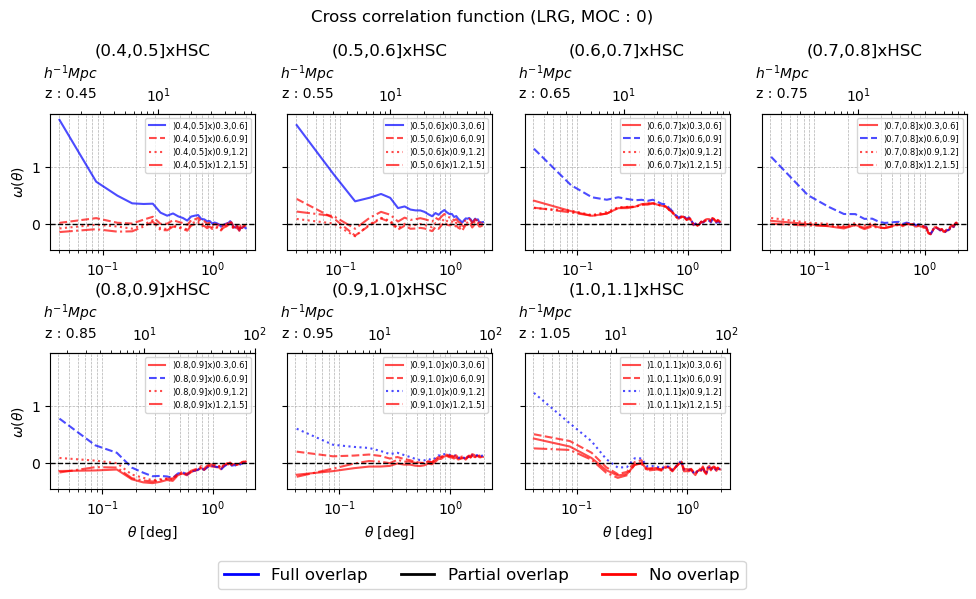

In [22]:
file_reader = cu.CorrFileReader('../crosscorr/run19/')
tgt = 'LRG'
bhsc = file_reader.get_bins('HSC')
btgt = file_reader.get_bins(tgt)
moc_idx = 0

cmap = plt.get_cmap('rainbow')
fig, axs = plt.subplots(2, 4, sharey=True, figsize=(10, 6))

axs = axs.flatten()
if tgt == 'LRG':
    fig.delaxes(axs[-1])
axs = axs[:len(btgt)-1]

for i, ax in enumerate(axs, start=1):
    for j in range(1, len(bhsc)):
        result = TwoPointCorrelationFunction.load(
            file_reader.get_file(i, j, moc_idx, tgt)
        )
        
        # Define bin edges
        btgt_min, btgt_max = btgt[i-1], btgt[i]
        bhsc_min, bhsc_max = bhsc[j-1], bhsc[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min and bhsc_max >= btgt_max:
            color = 'blue'  # Full overlap
        elif bhsc_max <= btgt_min or bhsc_min >= btgt_max:
            color = 'red'   # No overlap
        else:
            color = 'black' # Partial overlap
        ls = '-' 
        if j == 2:
            ls = '--'
        if j == 3:
            ls = ':'
        if j == 4:
            ls = '-.'
        ax.plot(
            result.sep, 
            result.corr, 
            alpha=0.7,
            linestyle=ls,
            label=f'){btgt[i-1]:.1f},{btgt[i]:.1f}]x){bhsc[j-1]:.1f},{bhsc[j]:.1f}]',
            color=color,
            )
        if i > 4:
            ax.set_xlabel(r'$\theta$ [deg]')
        if i == 1 or i == 5:
            ax.set_ylabel(r'$\omega(\theta)$')

    ax.grid(True, which='both', linestyle='--', lw=0.5)
    ax.set_xscale('log')
    ax.axhline(0, color='k', linestyle='--', lw=1)
    ax.set_title(f'({btgt[i-1]:.1f},{btgt[i]:.1f}]xHSC', fontsize=12)
    ax.legend(loc='upper right', fontsize=6)

    mid_z = (btgt[i-1] + btgt[i]) / 2
    tohMpc = lambda x, z=mid_z: ct.arcsec2hMpc(x * 3600, z=z)
    toArcsec = lambda theta, z=mid_z: ct.hMpc2arcsec(theta, z=z) / 3600

    secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
    secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz : {mid_z:.2f}\n')
    secax.xaxis.set_label_coords(0.1, 1.1)
            
fig.suptitle(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)
fig.tight_layout()

# overlap types
custom_lines = [
    mlines.Line2D([0], [0], color='blue', lw=2),
    mlines.Line2D([0], [0], color='black', lw=2),
    mlines.Line2D([0], [0], color='red', lw=2)
    ]
fig.legend(
    custom_lines, 
    [
        'Full overlap', 
        'Partial overlap', 
        'No overlap'
        ], 
    loc='lower center', 
    ncol=3, 
    bbox_to_anchor=(0.5, 0), 
    fontsize=12
    )
plt.subplots_adjust(bottom=0.18)

In [16]:
table = fio.FITS(Path(
                    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
                    ))

In [18]:
pz = table[1]['dnnz_photoz_best'].read()

Text(0.5, 1.0, 'Photo-z distribution (HSC)')

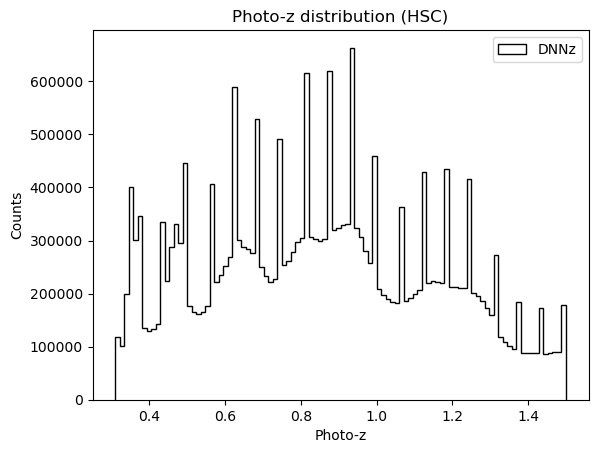

In [19]:
plt.hist(pz, bins=100, histtype='step', color='k', lw=2, label='DNNz')
plt.xlabel('Photo-z')
plt.ylabel('Counts')
plt.legend()
plt.title('Photo-z distribution (HSC)')

In [ ]:
import fitsio as fio
import os

os.listdir('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/')

In [82]:
tbl = fio.FITS(
    '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_clustering.dat.fits'
    )

In [83]:
sz = tbl[1]['Z'].read()

In [87]:
min(sz), max(sz)

(0.8000000181478555, 1.5999997110135349)

In [ ]:
len(sz)
bins_bgs = np.arange(0, 0.6, 0.1) # 0 < z < 0.6
bins_lrg = np.arange(0.4, 1.2, 0.1) # 0.4 < z < 1
bhsc = np.arange(0.8, 1.7, 0.1) # 0.6 < z < 1.6 => 0.8 < z < 1.6 in redshift distribution
bins_qso = np.arange(0.8, 3.4, 0.1) # 0.9 < z < 2.1

Text(0.5, 1.0, 'ELGnotqso redshift distribution')

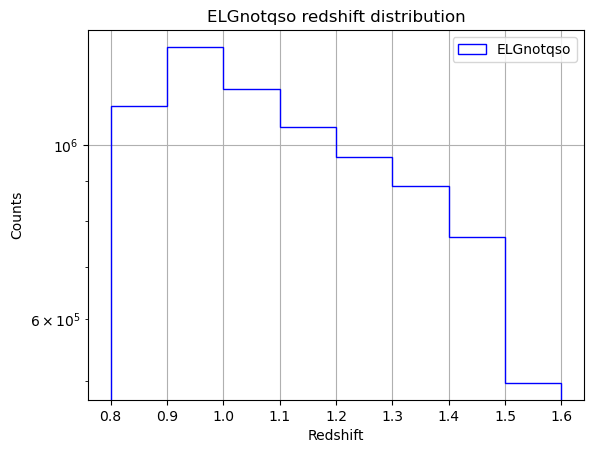

In [ ]:
plt.hist(sz, bins=bhsc, histtype='step', color='blue', lw=2, label='ELGnotqso')
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('ELGnotqso redshift distribution')

In [20]:
cat = fio.FITS(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
    )
cat[1].get_colnames()
pz = cat[1]['dnnz_photoz_best'].read()

1.5 0.31


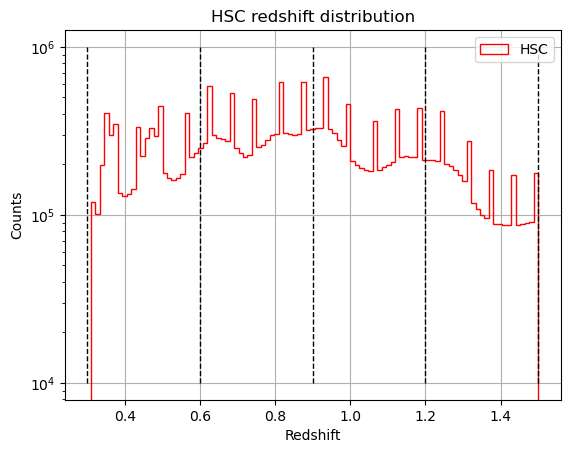

In [26]:
#bins_hsc = np.arange(0.3, 1.8, 0.3)
plt.hist(pz, bins=100, histtype='step', color='red', lw=2, label='HSC')
plt.vlines(
    [0.3, 0.6, 0.9, 1.2, 1.5], 
    ymin=1e4, ymax=1e6,
    color='black', linestyle='--', lw=1
    )
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('HSC redshift distribution')
print(max(pz), min(pz))